In [2]:
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM

# Load the catalog
cat = Table.read("../data/agn-v1.0.fits")

# Preview available columns
print(cat.colnames)

['Source_Name', 'RA', 'DEC', 'E_RA', 'E_DEC', 'Total_flux', 'E_Total_flux', 'Peak_flux', 'E_Peak_flux', 'S_Code', 'Mosaic_ID', 'Maj', 'Min', 'PA', 'E_Maj', 'E_Min', 'E_PA', 'DC_Maj', 'DC_Min', 'DC_PA', 'Isl_rms', 'FLAG_WORKFLOW', 'ID_flag', 'Prefilter', 'Postfilter', 'lr_fin', 'optRA', 'optDec', 'Composite_Size', 'Composite_Width', 'Composite_PA', 'Assoc', 'ID_Qual', 'Assoc_Qual', 'Blend_prob', 'Other_prob', 'Created', 'Position_from', 'Renamed_from', 'ID_RA', 'ID_DEC', 'UID_L', 'UNWISE_OBJID', 'ID_NAME', 'Separation_1a', 'Legacy_ID', 'HPX', 'release', 'brickid', 'objid', 'maskbits', 'fracflux_g', 'fracflux_r', 'fracflux_z', 'type', 'ra', 'dec', 'pstar', 'star', 'ANYMASK_OPT', 'gmmcomp', 'zphot', 'zphot_err', 'var.density', 'var.tr.noise', 'var.in.noise', 'flag_qual', 'zspec_sdss', 'zwarning_sdss', 'plate_sdss', 'mjd_sdss', 'fiberid_sdss', 'z_hetdex', 'z_hetdex_conf', 'hetdex_sourceid', 'z_desi', 'z_desi_err', 'desi_sourceid', '2RXS_ID_1', 'XMMSL2_ID', 'Resolved', 'LAS', 'z_best', 'z_s

In [3]:
#defining custom units
import astropy.units as u

u.def_unit('dex(solMass)')
u.add_enabled_units([u.Unit('dex(solMass)')])

In [4]:
#testing critical columns
print(cat['z_best'][:5])
print(cat['L_144'][:5])
print(cat['LAS'][:5])
print(cat['Resolved'][:5])


  z_best 
---------
0.9046737
0.5326388
0.8939777
0.6302657
0.6602352
        L_144         
        W / Hz        
----------------------
 5.221798563819946e+24
2.8199044036013605e+24
 7.081438527354731e+24
1.7676742700413785e+24
2.0167606946126062e+24
       LAS        
      arcsec      
------------------
11.897294243545817
 67.16943878895957
 9.567408250937318
 6.578691975981505
10.165625312368446
Resolved
--------
   False
    True
   False
   False
   False


<>:43: SyntaxWarning: invalid escape sequence '\ '
<>:43: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_4330/1181942449.py:43: SyntaxWarning: invalid escape sequence '\ '
  plt.ylabel('L$_{144\ \\mathrm{MHz}}$ (W Hz$^{-1}$)')


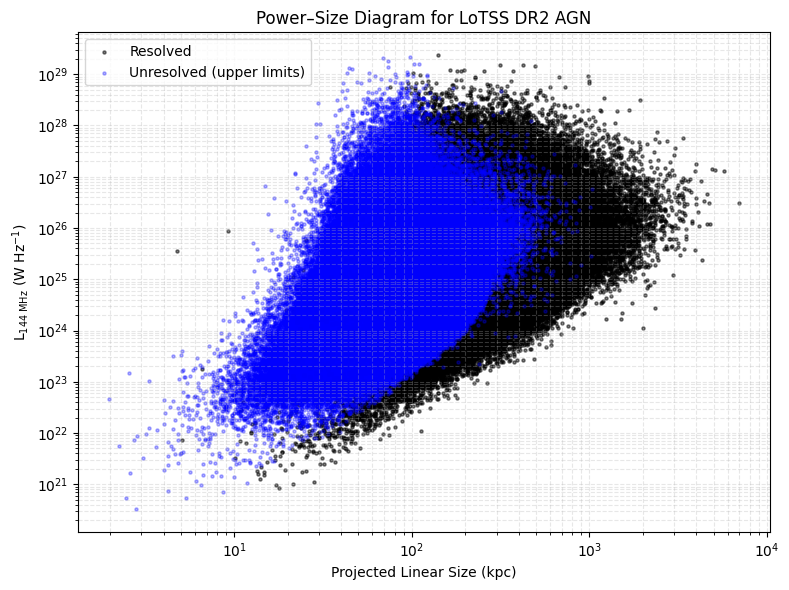

In [9]:
#trying out the power-size diagram
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
from astropy.table import Table

# Load catalog
cat = Table.read("../data/agn-v1.0.fits")

# Extract required fields
z = cat['z_best'].data
lum = cat['L_144'].data  # in W/Hz
ang_size_arcsec = cat['LAS'].data  # in arcsec
resolved = cat['Resolved'].data

# Set up cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# Convert angular size (arcsec) → radians
ang_size_rad = ang_size_arcsec * (np.pi / (180.0 * 3600.0))

# Compute angular diameter distance in kpc
D_A = cosmo.angular_diameter_distance(z).to(u.kpc).value  # returns array

# Compute projected physical size in kpc
phys_size_kpc = D_A * ang_size_rad

# Create plot
plt.figure(figsize=(8,6))

# Plot resolved sources
plt.scatter(phys_size_kpc[resolved], lum[resolved],
            s=5, c='black', alpha=0.5, label='Resolved')

# Plot unresolved as upper limits
plt.scatter(phys_size_kpc[~resolved], lum[~resolved],
            s=5, c='blue', alpha=0.3, label='Unresolved (upper limits)')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Projected Linear Size (kpc)')
plt.ylabel('L$_{144\ \\mathrm{MHz}}$ (W Hz$^{-1}$)')
plt.title('Power–Size Diagram for LoTSS DR2 AGN')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.3)
plt.tight_layout()
plt.show()
